# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

Trabajaremos con un conjunto de datos **libre y de fácil descarga** desde el paquete `medmnist`: **OCTMNIST**, un dataset de imágenes de tomografía de coherencia óptica de retina en formato 2D, con cuatro clases (CNV, DME, drusas y normal).

Al final tendrás:
- Un modelo CNN entrenado desde cero.
- Un ejemplo de **transfer learning** usando un modelo preentrenado.
- Evaluación con métricas útiles en contexto médico.
- Un vistazo a interpretabilidad con **Grad-CAM**.

⚠️ Nota importante (contexto médico): este material es educativo. Un modelo entrenado aquí **no** debe usarse para diagnóstico clínico sin validación rigurosa, controles de sesgo, y aprobación regulatoria.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (OCTMNIST)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset en este ejercicio:

- Entrada: imágenes 2D de tomografía de coherencia óptica (OCT) de la retina, de 28 × 28 píxeles.
- Etiquetas: clasificación multiclase de cuatro categorías (CNV, DME, drusas y normal).
- Particiones: train/val/test ya vienen definidas.

In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

# Fijo la semilla antes de crear los modelos y mezclar los datos.
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

data_flag = "octmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info

{'python_class': 'OCTMNIST',
 'description': 'The OCTMNIST is based on a prior dataset of 109,309 valid optical coherence tomography (OCT) images for retinal diseases. The dataset is comprised of 4 diagnosis categories, leading to a multi-class classification task. We split the source training set with a ratio of 9:1 into training and validation set, and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−1,536)×(277−512). We center-crop the images and resize them into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/octmnist.npz?download=1',
 'MD5': 'c68d92d5b585d8d81f7112f81e2d0842',
 'url_64': 'https://zenodo.org/records/10519652/files/octmnist_64.npz?download=1',
 'MD5_64': 'e229e9440236b774d9f0dfef9d07bdaf',
 'url_128': 'https://zenodo.org/records/10519652/files/octmnist_128.npz?download=1',
 'MD5_128': '0a97e76651ace45c5d943ee3f65b63ae',
 'url_224': 'https://zenodo.org/records/10519652/files/octmnist_224.npz?downl

In [3]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)

100%|██████████| 54.9M/54.9M [00:53<00:00, 1.03MB/s]


(97477, 10832, 1000)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


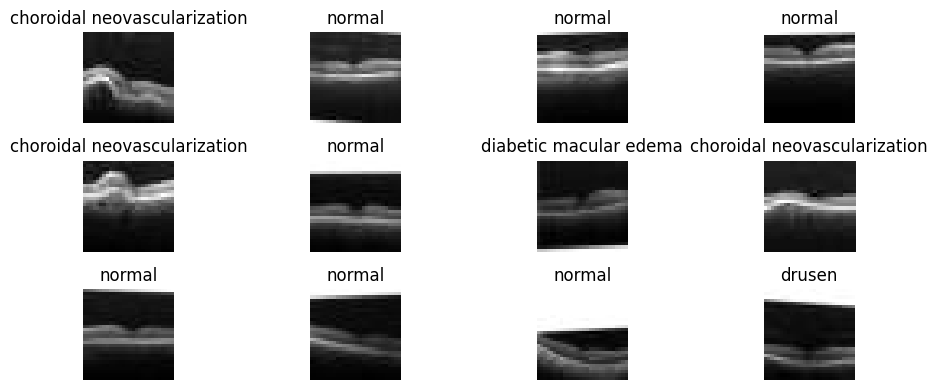

In [4]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))

    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i + 1)

        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")

        clase = int(y.item())
        plt.title(info["label"][str(clase)])

        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)

## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Uso cero procesos auxiliares para evitar problemas en notebooks de Windows.
num_workers = 0
pin_memory = device.type == "cuda"
print(f"Dispositivo: {device}. El entrenamiento completo en CPU puede tardar bastante.")
device


Dispositivo: cuda. El entrenamiento completo en CPU puede tardar bastante.


device(type='cuda')

In [6]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 1, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [7]:
import torch.nn as nn

num_classes = len(info["label"])  # OCTMNIST tiene 4 clases

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=64, out_features=4, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [8]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in tqdm(loader, desc="Evaluación", leave=False):
        x = x.to(device)
        y = y.to(device).long().reshape(-1)

        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(
        y_true,
        y_prob,
        multi_class="ovr",
        average="macro",
        labels=np.arange(num_classes)
    )

    return acc, auc, y_true, y_pred, y_prob


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    # Congelar parámetros no congela las estadísticas de BatchNorm.
    # Mantengo en evaluación las BatchNorm de las capas congeladas.
    for module in model.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            if not any(p.requires_grad for p in module.parameters()):
                module.eval()
    total_loss = 0.0
    total_samples = 0

    for x, y in tqdm(loader, desc="Entrenamiento", leave=False):
        x = x.to(device)
        y = y.to(device).long().reshape(-1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total_samples += y.size(0)

    return total_loss / total_samples


### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=4,
    gamma=0.5
)

epochs = 8
history_scratch = {"train_loss": [], "val_acc": [], "val_auc": [], "lr": []}

for epoch in range(1, epochs + 1):
    lr_actual = optimizer.param_groups[0]["lr"]

    train_loss = train_one_epoch(
        model_scratch, train_loader, optimizer, criterion
    )
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)
    history_scratch["lr"].append(lr_actual)

    print(
        f"Epoch {epoch:02d} | lr={lr_actual:.6f} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | val_auc={val_auc:.4f}"
    )

    scheduler.step()

Epoch 01 | lr=0.001000 | train_loss=0.5991 | val_acc=0.8340 | val_auc=0.9243


Epoch 02 | lr=0.001000 | train_loss=0.4586 | val_acc=0.6188 | val_auc=0.8796


Epoch 03 | lr=0.001000 | train_loss=0.4105 | val_acc=0.8521 | val_auc=0.9448


Epoch 04 | lr=0.001000 | train_loss=0.3910 | val_acc=0.8509 | val_auc=0.9441


Epoch 05 | lr=0.000500 | train_loss=0.3660 | val_acc=0.8657 | val_auc=0.9496


Epoch 06 | lr=0.000500 | train_loss=0.3563 | val_acc=0.8617 | val_auc=0.9504


Epoch 07 | lr=0.000500 | train_loss=0.3474 | val_acc=0.8858 | val_auc=0.9572


Epoch 08 | lr=0.000500 | train_loss=0.3420 | val_acc=0.8341 | val_auc=0.9457


### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


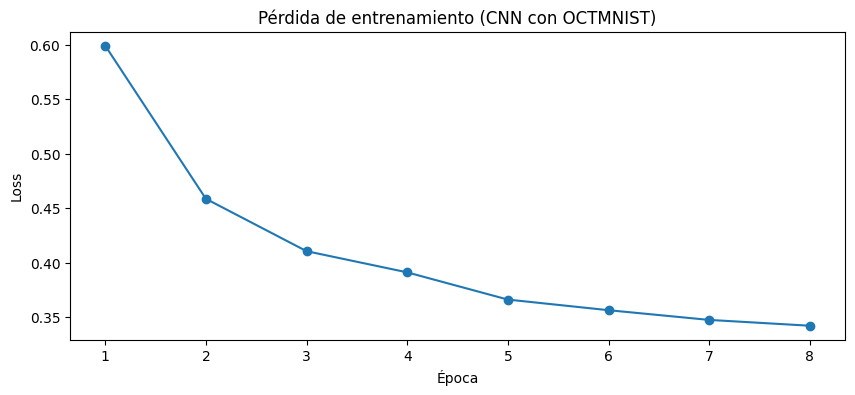

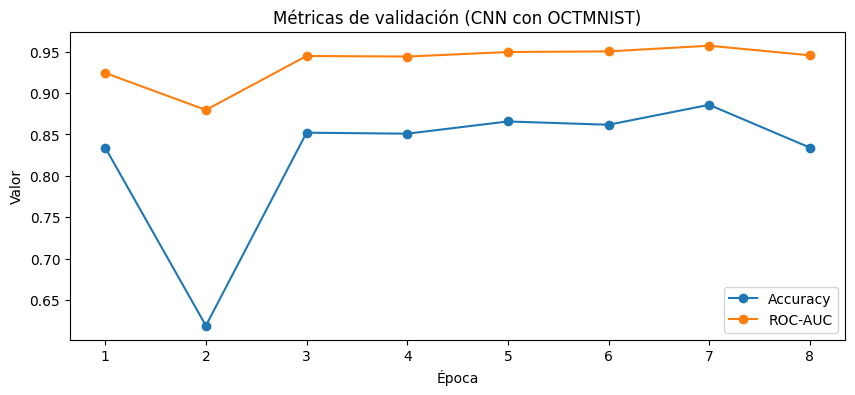

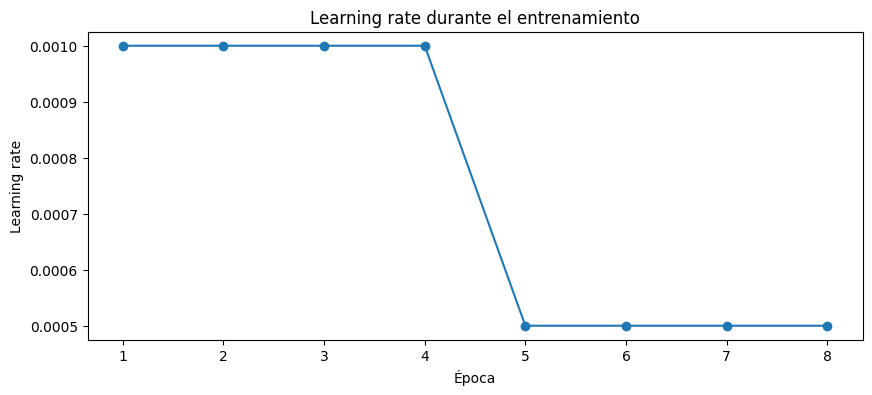

In [10]:
epocas = range(1, len(history_scratch["train_loss"]) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epocas, history_scratch["train_loss"], marker="o")
plt.title("Pérdida de entrenamiento (CNN con OCTMNIST)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epocas, history_scratch["val_acc"], marker="o", label="Accuracy")
plt.plot(epocas, history_scratch["val_auc"], marker="o", label="ROC-AUC")
plt.title("Métricas de validación (CNN con OCTMNIST)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epocas, history_scratch["lr"], marker="o")
plt.title("Learning rate durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Learning rate")
plt.show()

### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [11]:
class_names = [info["label"][str(i)] for i in range(num_classes)]

test_acc, test_auc, y_true, y_pred, y_prob = evaluate(
    model_scratch, test_loader
)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC multiclase: {test_auc:.4f}")
print()

print(classification_report(
    y_true,
    y_pred,
    labels=range(num_classes),
    target_names=class_names,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=range(num_classes)
)
cm


Test accuracy: 0.6930
Test ROC-AUC multiclase: 0.9499

                              precision    recall  f1-score   support

choroidal neovascularization     0.7153    0.8440    0.7743       250
      diabetic macular edema     0.7012    0.9480    0.8061       250
                      drusen     1.0000    0.0640    0.1203       250
                      normal     0.6524    0.9160    0.7621       250

                    accuracy                         0.6930      1000
                   macro avg     0.7672    0.6930    0.6157      1000
                weighted avg     0.7672    0.6930    0.6157      1000



array([[211,  32,   0,   7],
       [  5, 237,   0,   8],
       [ 76,  51,  16, 107],
       [  3,  18,   0, 229]])

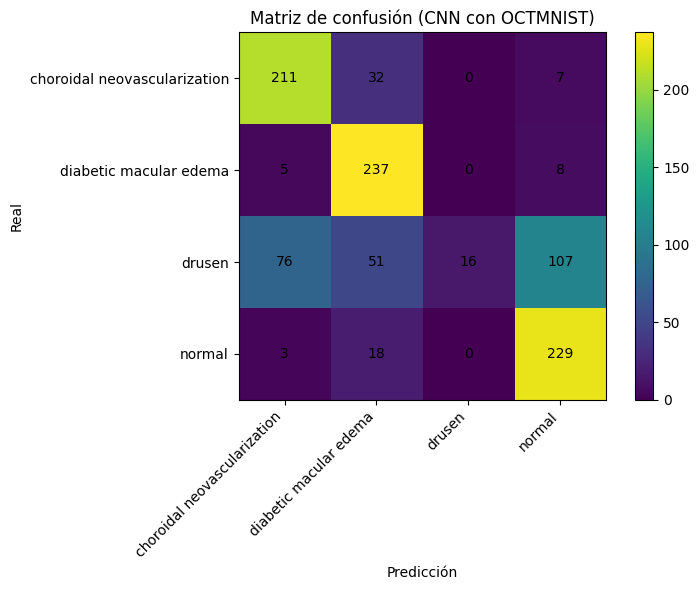

In [12]:
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN con OCTMNIST)")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [13]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(
    split="train",
    transform=transform_aug,
    download=True
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

In [14]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=4,
    gamma=0.5
)

epochs = 8
history_aug = {"train_loss": [], "val_acc": [], "val_auc": [], "lr": []}

for epoch in range(1, epochs + 1):
    lr_actual = optimizer.param_groups[0]["lr"]

    train_loss = train_one_epoch(
        model_aug, train_loader_aug, optimizer, criterion
    )
    val_acc, val_auc, _, _, _ = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)
    history_aug["lr"].append(lr_actual)

    print(
        f"Epoch {epoch:02d} | lr={lr_actual:.6f} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | val_auc={val_auc:.4f}"
    )

    scheduler.step()

Epoch 01 | lr=0.001000 | train_loss=0.6851 | val_acc=0.8030 | val_auc=0.9038


Epoch 02 | lr=0.001000 | train_loss=0.5516 | val_acc=0.7520 | val_auc=0.8870


Epoch 03 | lr=0.001000 | train_loss=0.5123 | val_acc=0.8335 | val_auc=0.9302


Epoch 04 | lr=0.001000 | train_loss=0.4925 | val_acc=0.8462 | val_auc=0.9356


Epoch 05 | lr=0.000500 | train_loss=0.4705 | val_acc=0.8381 | val_auc=0.9389


Epoch 06 | lr=0.000500 | train_loss=0.4595 | val_acc=0.8572 | val_auc=0.9433


Epoch 07 | lr=0.000500 | train_loss=0.4546 | val_acc=0.8687 | val_auc=0.9467


Epoch 08 | lr=0.000500 | train_loss=0.4477 | val_acc=0.8466 | val_auc=0.9366


### 6.1. Comparación rápida


In [15]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.6930 | test_auc=0.9499
Con augmentation  | test_acc=0.6780 | test_auc=0.9474


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [16]:
import torchvision.models as models

normalizar_imagenet = T.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    normalizar_imagenet
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    normalizar_imagenet
])

train_dataset_tl = DataClass(
    split="train", transform=transform_tl_train, download=True
)
val_dataset_tl = DataClass(
    split="val", transform=transform_tl_eval, download=True
)
test_dataset_tl = DataClass(
    split="test", transform=transform_tl_eval, download=True
)

train_loader_tl = DataLoader(
    train_dataset_tl, batch_size=64, shuffle=True,
    num_workers=num_workers, pin_memory=pin_memory
)
val_loader_tl = DataLoader(
    val_dataset_tl, batch_size=64, shuffle=False,
    num_workers=num_workers, pin_memory=pin_memory
)
test_loader_tl = DataLoader(
    test_dataset_tl, batch_size=64, shuffle=False,
    num_workers=num_workers, pin_memory=pin_memory
)

next(iter(train_loader_tl))[0].shape

torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [17]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=0.7124 | val_acc=0.7723 | val_auc=0.8756


Stage1 Epoch 02 | train_loss=0.6271 | val_acc=0.7726 | val_auc=0.8769


Stage1 Epoch 03 | train_loss=0.6067 | val_acc=0.7733 | val_auc=0.8826


Stage1 Epoch 04 | train_loss=0.6004 | val_acc=0.7698 | val_auc=0.8796


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.

**Nota de ejecución:** el archivo original registra un `KeyboardInterrupt` en esta
etapa: la ejecución se interrumpió antes de terminar. Esto no identifica por sí solo
un error del modelo. Las barras de progreso permiten observar el avance por lotes.
OCTMNIST completo y ResNet18 a 224 × 224 pueden tardar bastante, especialmente en CPU.
Si interrumpes una etapa, vuelve a ejecutar desde la creación del modelo y su
optimizador para obtener una comparación con el entrenamiento completo.


In [19]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]

len(trainable_params)


17

In [20]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=2,
    gamma=0.5
)

epochs = 4
history_tl_stage2 = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": [],
    "lr": []
}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate(
        resnet,
        val_loader_tl
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)
    history_tl_stage2["lr"].append(current_lr)

    print(
        f"Stage2 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f} | "
        f"lr={current_lr:.6f}"
    )

    scheduler.step()

Stage2 Epoch 01 | train_loss=0.4615 | val_acc=0.8805 | val_auc=0.9527 | lr=0.000100


Stage2 Epoch 02 | train_loss=0.3409 | val_acc=0.8817 | val_auc=0.9534 | lr=0.000100


Stage2 Epoch 03 | train_loss=0.2948 | val_acc=0.8845 | val_auc=0.9609 | lr=0.000050


Stage2 Epoch 04 | train_loss=0.2785 | val_acc=0.9003 | val_auc=0.9634 | lr=0.000050


### 7.3. Evaluación en test del modelo con transfer learning


In [21]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(
    y_true_tl, y_pred_tl, labels=range(num_classes),
    target_names=class_names, digits=4, zero_division=0
))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl, labels=range(num_classes))
cm_tl


Transfer learning | test_acc=0.7100 | test_auc=0.9527

                              precision    recall  f1-score   support

choroidal neovascularization     0.6101    0.9640    0.7473       250
      diabetic macular edema     0.9459    0.7000    0.8046       250
                      drusen     0.9630    0.2080    0.3421       250
                      normal     0.6612    0.9680    0.7857       250

                    accuracy                         0.7100      1000
                   macro avg     0.7951    0.7100    0.6699      1000
                weighted avg     0.7951    0.7100    0.6699      1000



array([[241,   4,   2,   3],
       [ 65, 175,   0,  10],
       [ 85,   2,  52, 111],
       [  4,   4,   0, 242]])

### 7.4. Comparación global (resumen)


In [22]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.6930 | auc=0.9499
CNN desde cero (con aug)  | acc=0.6780 | auc=0.9474
Transfer learning (ResNet) | acc=0.7100 | auc=0.9527


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [23]:
# Calculo Grad-CAM incluso si el extractor está congelado y ajusto su tamaño.
import torch
import torch.nn.functional as F

def grad_cam(model, image_tensor, target_class=None):
    was_training = model.training
    model.eval()
    activations = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    handle = model.layer4.register_forward_hook(forward_hook)
    try:
        with torch.enable_grad():
            # El gradiente de la entrada permite explicar también la fase congelada.
            image = image_tensor.detach().to(next(model.parameters()).device)
            image = image.unsqueeze(0).requires_grad_(True)
            logits = model(image)
            if target_class is None:
                target_class = int(logits.argmax(dim=1).item())
            if not 0 <= target_class < logits.shape[1]:
                raise ValueError("La clase objetivo no existe en el modelo.")

            act = activations["value"]
            grad = torch.autograd.grad(logits[0, target_class], act)[0]
            weights = grad.mean(dim=(2, 3), keepdim=True)
            cam = torch.relu((weights * act).sum(dim=1, keepdim=True))
            cam = F.interpolate(
                cam, size=image_tensor.shape[-2:],
                mode="bilinear", align_corners=False
            )[0, 0]
            cam = cam - cam.min()
            cam = cam / cam.max().clamp_min(1e-8)
            return cam.detach().cpu().numpy(), target_class
    finally:
        # Retiro el hook incluso si ocurre un error para no acumular registros.
        handle.remove()
        model.train(was_training)


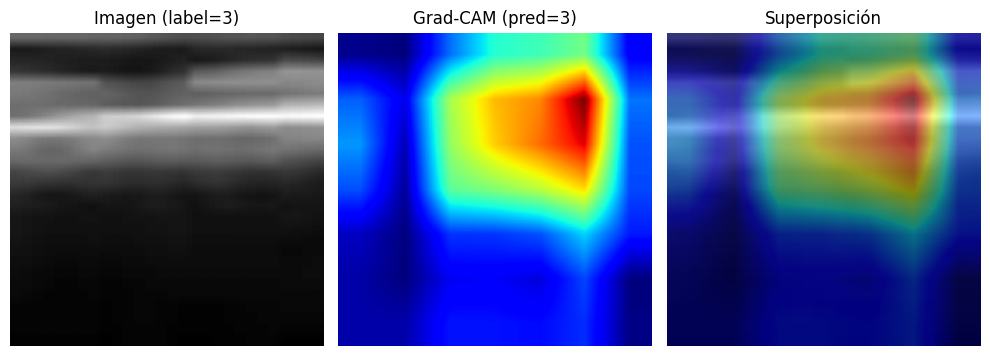

In [24]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

# Deshago la normalización de ImageNet para visualizar la imagen original.
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img = (x.cpu() * std + mean).clamp(0, 1)[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet", vmin=0, vmax=1)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, cmap="jet", alpha=0.5, vmin=0, vmax=1)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [25]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']